<a href="https://colab.research.google.com/github/malikshahzaib263/neurofive-ml-track/blob/main/Week_2_Machine_Learning_Fundamentals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2 - Machine Learning Fundamentals

# Task 3: Predict Titanic Survival Using Logistic Regression

### Neurofive Solutions – Machine Learning Track

**Author:** Shahzaib Arshad

---

## Project Overview

The objective of this project is to build a machine learning classification model that predicts whether a passenger survived the Titanic disaster. The dataset is first prepared by selecting relevant features and encoding categorical variables. A Logistic Regression model is then trained using scikit-learn, and its performance is evaluated using accuracy, a confusion matrix, and a classification report.

## Objective

This project demonstrates the complete workflow of a binary classification problem.

The main objectives are:

- Prepare the Titanic dataset for machine learning.
- Encode categorical variables into numerical values.
- Split the dataset into training and testing sets.
- Train a Logistic Regression model.
- Evaluate model performance using standard classification metrics.
- Interpret the results using a confusion matrix.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

## Load Dataset

The Titanic dataset is loaded into a pandas DataFrame for further preprocessing and model development.


In [2]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [3]:
df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Dataset Information

Before building the model, it is important to inspect the dataset to understand its structure, data types, and missing values.


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## Data Cleaning

Missing values can negatively affect machine learning models.

The following preprocessing steps are performed:

- Missing values in **Age** are filled using the median.
- Missing values in **Embarked** are filled using the most frequent value (mode).
- The **Cabin** column is removed because it contains a large number of missing values.

In [7]:
df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df = df.drop(columns=["Cabin"])

In [8]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## Feature Selection

The target variable is **Survived**.

The following passenger information is used as input features:

- Passenger Class
- Sex
- Age
- Number of Siblings/Spouses
- Number of Parents/Children
- Fare
- Embarkation Port

In [9]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X = df[features]

y = df["Survived"]

## Data Preprocessing

Machine learning models require numerical data.

The categorical variables (**Sex** and **Embarked**) are converted into numerical values using **One-Hot Encoding**.

In [10]:
categorical_columns = [
    "Sex",
    "Embarked"
]

numeric_columns = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

preprocessor = ColumnTransformer(

    transformers=[

        (
            "cat",
            OneHotEncoder(drop="first"),
            categorical_columns
        )

    ],

    remainder="passthrough"

)

## Train-Test Split

The dataset is divided into:

- **80% Training Data**
- **20% Testing Data**

The training set is used to train the model, while the testing set evaluates its performance on unseen data.



In [11]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42

## Build Logistic Regression Model

A Logistic Regression classifier is created inside a pipeline so that preprocessing and model training occur together.

In [12]:
model = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("classifier", LogisticRegression(max_iter=1000))

    ]

)

In [13]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Sex', 'Embarked'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

## Make Predictions

The trained model predicts passenger survival on the testing dataset.


In [14]:
y_pred = model.predict(X_test)

In [15]:
results = pd.DataFrame({

    "Actual": y_test,

    "Predicted": y_pred

})

results.head(10)

,Actual,Predicted
709,1,0
439,0,0
840,0,0
720,1,1
39,1,1
290,1,1
300,1,1
333,0,0
208,1,1
136,1,1


## Model Accuracy

Accuracy represents the percentage of correctly classified passengers.

In [16]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy : {accuracy*100:.2f}%")

Accuracy : 81.01%


## Confusion Matrix

A confusion matrix compares the actual survival values with the model's predictions.

- Top-left: Correctly predicted passengers who did not survive.
- Bottom-right: Correctly predicted passengers who survived.
- Top-right and bottom-left: Incorrect predictions.

Higher values on the diagonal indicate better model performance.

In [17]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[90, 15],
       [19, 55]])

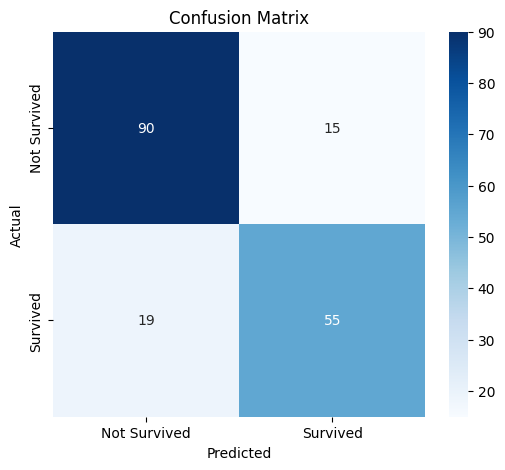

In [18]:
plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=["Not Survived","Survived"],

    yticklabels=["Not Survived","Survived"]

)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## Classification Report

The classification report provides additional evaluation metrics such as Precision, Recall, and F1-score for each class.

In [19]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



## Conclusion

A Logistic Regression model was successfully developed to predict passenger survival using the Titanic dataset.

The model was trained using selected passenger features and categorical variables were encoded using One-Hot Encoding. Model performance was evaluated using accuracy, a confusion matrix, and a classification report.

Overall, the model achieved good classification performance and demonstrates how Logistic Regression can be applied to solve binary classification problems.